# Session 09 Practical Activity: Hyperparameter Tuning and Pipelines

Build a reusable Scikit-learn pipeline, tune hyperparameters with cross-validation, and prepare a GitHub-ready result note.

**Goal:** predict `sla_breach_risk` using only safe pre-prediction fields. Exclude columns ending with `DO_NOT_USE`.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

RANDOM_STATE = 42
DATA_PATH = Path('data/workplace_pipeline_tuning_dataset.csv')
df = pd.read_csv(DATA_PATH)
df.head()

,request_id,request_channel,service_area,request_type,customer_segment,priority_at_submission,request_age_hours_at_triage,previous_tickets_90d,open_items_for_team,staff_available,attachments_count,has_clear_description,historical_team_delay_rate,requester_tenure_months,day_of_week,sla_breach_risk,post_resolution_hours_DO_NOT_USE,final_status_DO_NOT_USE
0,REQ-10000,Email,Facilities,Policy query,Key client,Low,7.5,2,44,11,4,1,0.095,73.0,Mon,1,58.3,Resolved late
1,REQ-10001,Email,HR,Policy query,Internal,Urgent,9.6,2,64,10,2,0,0.147,53.0,Fri,1,71.3,Resolved late
2,REQ-10002,Chat,Data,Payroll,Key client,Standard,34.9,2,27,7,0,1,0.390,53.0,Wed,0,31.3,Auto closed
3,REQ-10003,Chat,Facilities,Data report,External supplier,Urgent,20.5,1,42,7,1,1,0.275,10.0,Mon,0,35.7,Auto closed
4,REQ-10004,Email,IT,Procurement,Internal,Urgent,4.6,2,51,2,2,1,0.373,27.0,Mon,1,61.4,Resolved late


## 1. Inspect the dataset and define safe columns

In [4]:
print('Shape:', df.shape)
print(df.dtypes)
print('Target balance:')
print(df['sla_breach_risk'].value_counts(normalize=True).round(3))

leakage_cols = [c for c in df.columns if c.endswith('DO_NOT_USE')]
identifier_cols = ['request_id']
target = 'sla_breach_risk'
feature_cols = [c for c in df.columns if c not in leakage_cols + identifier_cols + [target]]

print('Leakage columns excluded:', leakage_cols)
print('Feature columns used:', feature_cols)

Shape: (850, 18)
request_id                              str
request_channel                         str
service_area                            str
request_type                            str
customer_segment                        str
priority_at_submission                  str
request_age_hours_at_triage         float64
previous_tickets_90d                  int64
open_items_for_team                   int64
staff_available                       int64
attachments_count                     int64
has_clear_description                 int64
historical_team_delay_rate          float64
requester_tenure_months             float64
day_of_week                             str
sla_breach_risk                       int64
post_resolution_hours_DO_NOT_USE    float64
final_status_DO_NOT_USE                 str
dtype: object
Target balance:
sla_breach_risk
1    0.593
0    0.407
Name: proportion, dtype: float64
Leakage columns excluded: ['post_resolution_hours_DO_NOT_USE', 'final_status_DO_NOT_USE']


## 2. Train/test split and preprocessing routes

In [5]:
X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print('Numeric:', numeric_features)
print('Categorical:', categorical_features)

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

Numeric: ['request_age_hours_at_triage', 'previous_tickets_90d', 'open_items_for_team', 'staff_available', 'attachments_count', 'has_clear_description', 'historical_team_delay_rate', 'requester_tenure_months']
Categorical: ['request_channel', 'service_area', 'request_type', 'customer_segment', 'priority_at_submission', 'day_of_week']


C:\Users\Chloe\AppData\Local\Temp\ipykernel_37300\2698403966.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()


## 3. Baseline pipeline: Logistic Regression

              precision    recall  f1-score   support

           0       0.58      0.43      0.49        87
           1       0.66      0.79      0.72       126

    accuracy                           0.64       213
   macro avg       0.62      0.61      0.61       213
weighted avg       0.63      0.64      0.63       213

ROC-AUC: 0.654


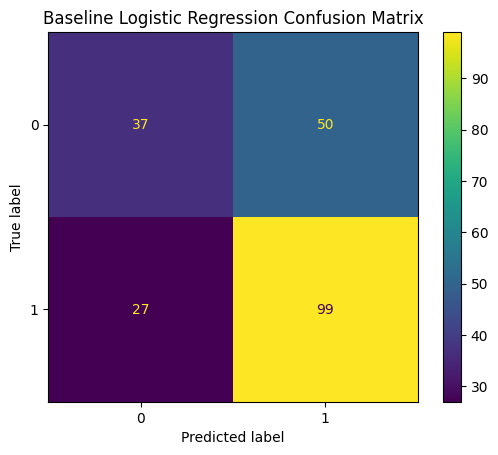

In [6]:
logistic_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logistic_pipeline.fit(X_train, y_train)
preds = logistic_pipeline.predict(X_test)
probs = logistic_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print('ROC-AUC:', round(roc_auc_score(y_test, probs), 3))
ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.title('Baseline Logistic Regression Confusion Matrix')
plt.show()

## 4. GridSearchCV: controlled search over a small space

In [7]:
grid_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    'model__C': [0.5, 1.0, 3.0],
    'model__class_weight': [None, 'balanced'],
    'preprocess__num__imputer__strategy': ['median']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    grid_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)
print('Best recall:', round(grid_search.best_score_, 3))
print('Best parameters:', grid_search.best_params_)

Best recall: 0.678
Best parameters: {'model__C': 0.5, 'model__class_weight': 'balanced', 'preprocess__num__imputer__strategy': 'median'}


## 5. RandomizedSearchCV: larger search under a budget

In [8]:
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

param_distributions = {
    'model__n_estimators': [60, 100],
    'model__max_depth': [None, 6, 10],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

random_search.fit(X_train, y_train)
print('Best recall:', round(random_search.best_score_, 3))
print('Best parameters:', random_search.best_params_)

Best recall: 0.681
Best parameters: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 6, 'model__class_weight': 'balanced'}


## 6. Compare tuned models on the holdout set

In [9]:
candidates = {
    'Tuned Logistic Regression': grid_search.best_estimator_,
    'Tuned Random Forest': random_search.best_estimator_
}

rows = []
for name, model in candidates.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, pred, output_dict=True)
    rows.append({
        'model': name,
        'precision_pos': report['1']['precision'],
        'recall_pos': report['1']['recall'],
        'f1_pos': report['1']['f1-score'],
        'accuracy': report['accuracy'],
        'roc_auc': roc_auc_score(y_test, prob)
    })

results = pd.DataFrame(rows).round(3)
results

,model,precision_pos,recall_pos,f1_pos,accuracy,roc_auc
0,Tuned Logistic Regression,0.696,0.619,0.655,0.615,0.654
1,Tuned Random Forest,0.677,0.667,0.672,0.615,0.630


Selected model: Tuned Random Forest
              precision    recall  f1-score   support

           0       0.53      0.54      0.53        87
           1       0.68      0.67      0.67       126

    accuracy                           0.62       213
   macro avg       0.60      0.60      0.60       213
weighted avg       0.62      0.62      0.62       213



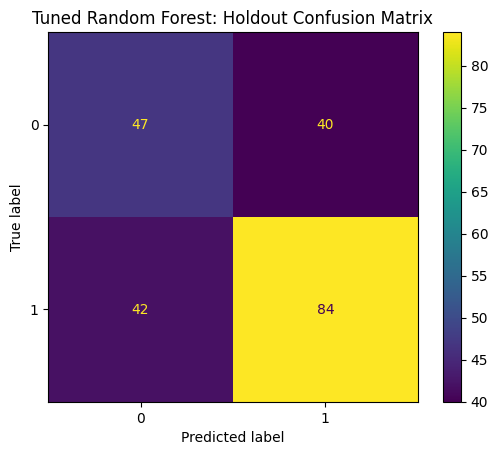

In [10]:
best_model_name = results.sort_values('recall_pos', ascending=False).iloc[0]['model']
best_model = candidates[best_model_name]
y_pred = best_model.predict(X_test)
print('Selected model:', best_model_name)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f'{best_model_name}: Holdout Confusion Matrix')
plt.show()

## 7. README result statement template

Use this in your GitHub README:

> I selected **[Random Forest]** because the tuning objective was **ROC_AUC**, which aligns with the business goal of catching SLA breach risk. The best parameters were **[n_estimators=100, max_depth=6, min_samples_split=10, min_samples_leaf=2, class_weight=balanced]**. The holdout result shows **[0.681]**, but the model should not be used without checking leakage columns, class imbalance, and subgroup performance.

## 8. Student task

1. Change the scoring metric from `recall` to `f1` or `roc_auc`.
2. Rerun the grid or random search.
3. Compare the selected parameters and explain what changed.
4. Commit your notebook and README to GitHub.

In [11]:
import os

# Create outputs folder if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# Save metrics table to CSV
results.to_csv('outputs/metrics_summary.csv', index=False)

print("Saved to outputs/metrics_summary.csv")

Saved to outputs/metrics_summary.csv
